# **Data Explanatory Analysis (Data Visualisation)**

## 1. Import Data

In [1]:
# Import libraries

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px

In [2]:
# Load Airbnb listings dataset
airbnb_proj_cleaned = pd.read_csv(
    "airbnb_cleaned.csv",
    encoding="latin1",      # latin1 handles special characters in European cities (Paris, Rome, etc.)
    low_memory=False,       # low_memory=False avoids dtype guessing issues
    on_bad_lines="skip"     # skips corrupted rows instead of breaking
)

In [3]:
airbnb_proj_cleaned.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 44 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279712 non-null  object 
 4   host_location                279712 non-null  object 
 5   host_response_time           279712 non-null  object 
 6   host_response_rate           279712 non-null  float64
 7   host_acceptance_rate         279712 non-null  float64
 8   host_total_listings_count    279712 non-null  float64
 9   neighbourhood                279712 non-null  object 
 10  city                         279712 non-null  object 
 11  latitude                     279712 non-null  float64
 12  longitude                    279712 non-null  float64
 13 

In [4]:
# Load Airbnb reviews dataset
reviews = pd.read_csv(
    "reviews.csv",
    encoding='latin1',
    low_memory=False,
    on_bad_lines='skip'
)

In [5]:
# Load Airbnb reviews dataset
reviews_cleaned = pd.read_csv(
    "airbnb_demand.csv",
    encoding='latin1',
    low_memory=False,
    on_bad_lines='skip'
)

In [6]:
reviews_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40251 entries, 0 to 40250
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   city                         40251 non-null  object
 1   neighbourhood                40251 non-null  object
 2   year                         40251 non-null  int64 
 3   month                        40251 non-null  int64 
 4   date                         40251 non-null  object
 5   review_count_neighbourhood   40251 non-null  int64 
 6   review_count_city            40251 non-null  int64 
 7   total_reviews_neighbourhood  40251 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 2.5+ MB


## 2. Price Analysis

### 2.1 Average Price by City

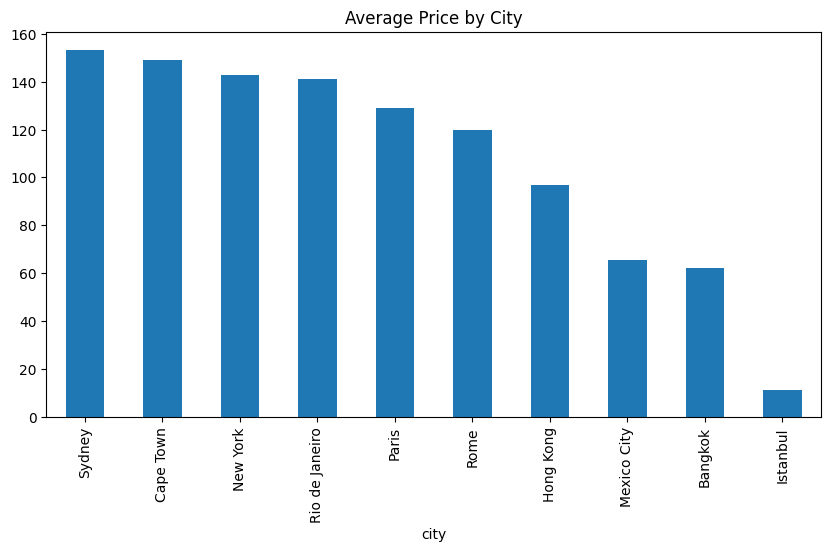

In [7]:
city_price = airbnb_proj_cleaned.groupby('city')['price_usd'].mean().sort_values(ascending=False)

city_price.plot(kind='bar', figsize=(10,5))
plt.title("Average Price by City")
plt.show()

### 2.2 Average Price by Room Type

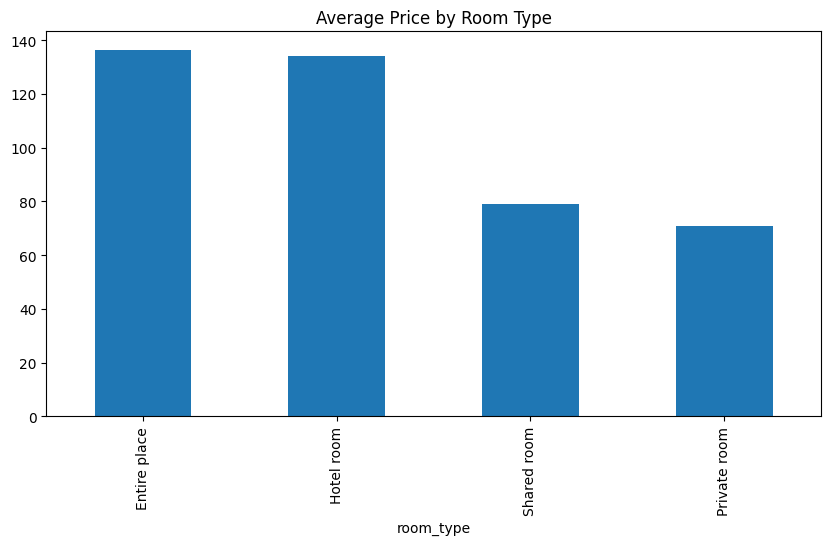

In [8]:
roomtype_price = airbnb_proj_cleaned.groupby('room_type')['price_usd'].mean().sort_values(ascending=False)

roomtype_price.plot(kind='bar', figsize=(10,5))
plt.title("Average Price by Room Type")
plt.show()

### 2.3 Average Price by Neighbor in Each City

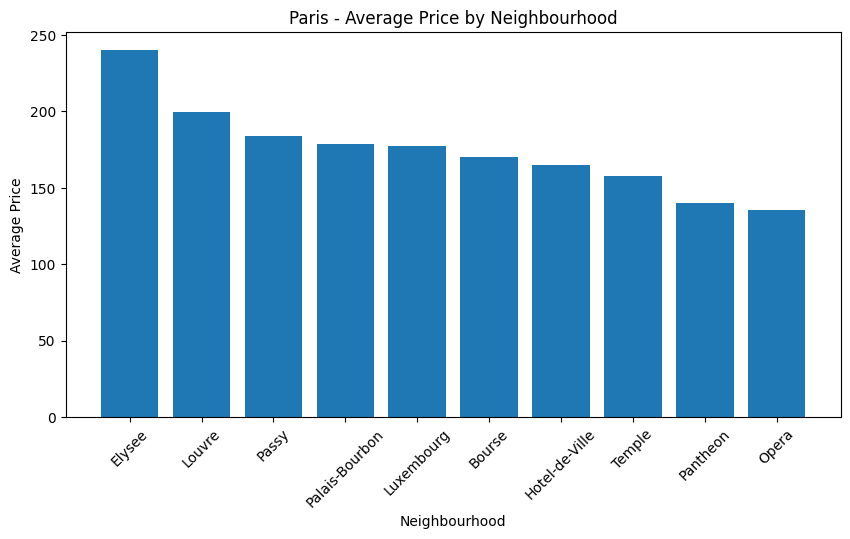

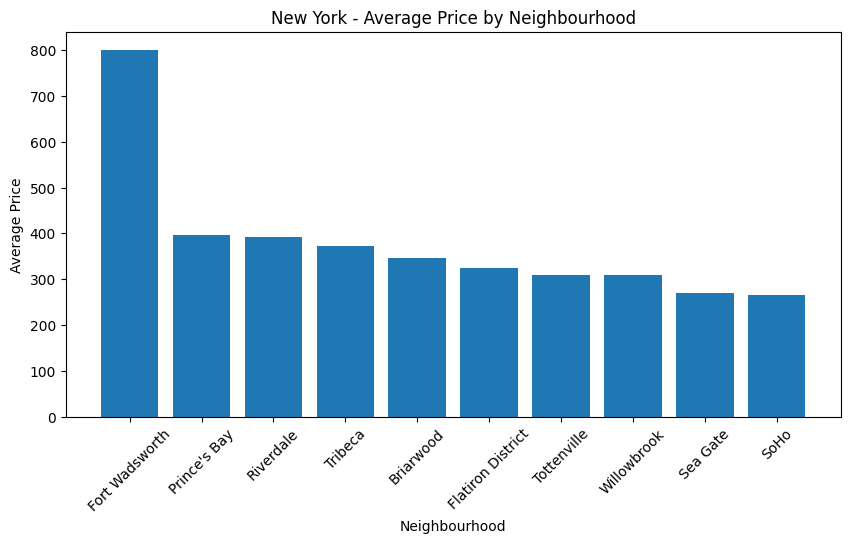

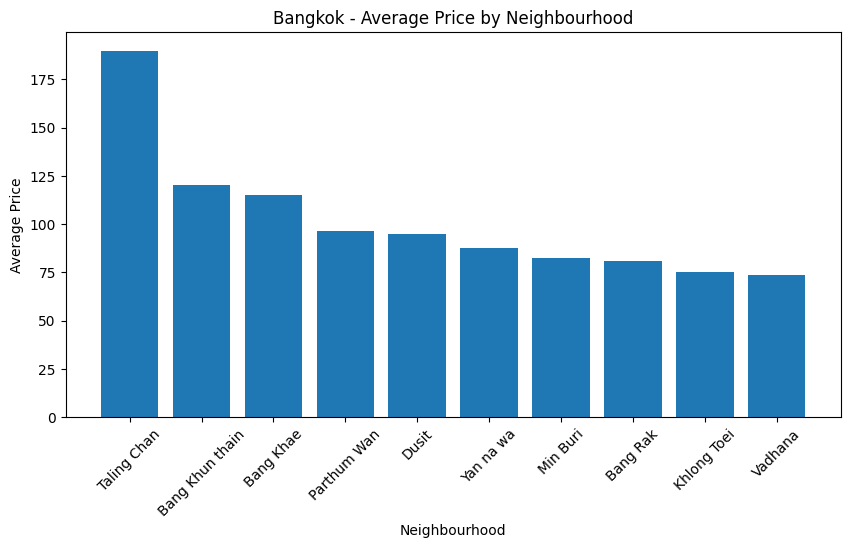

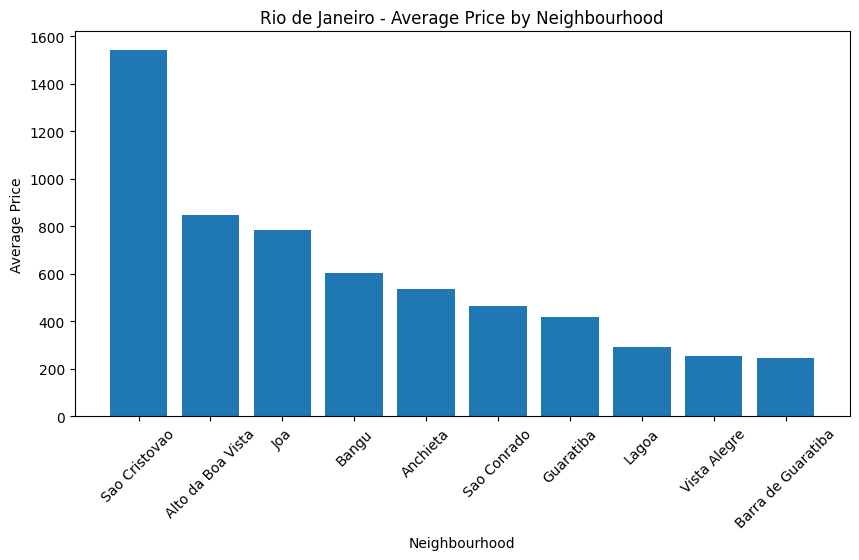

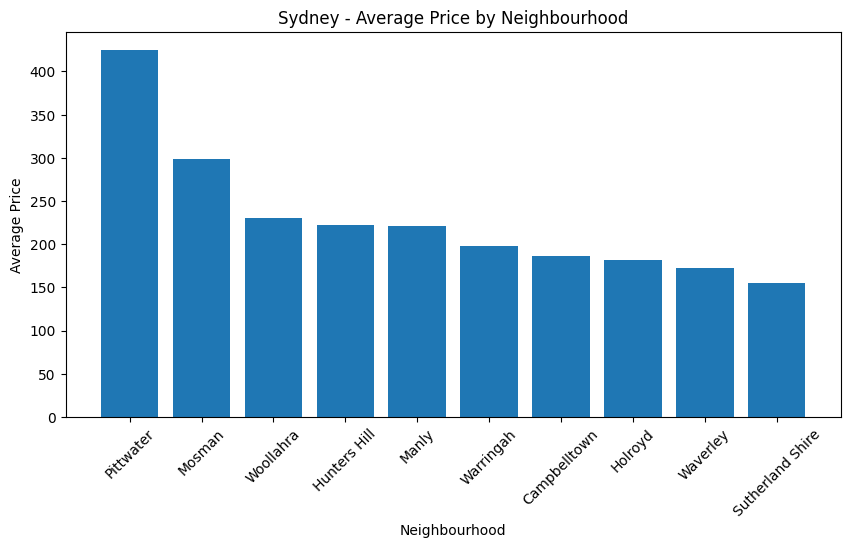

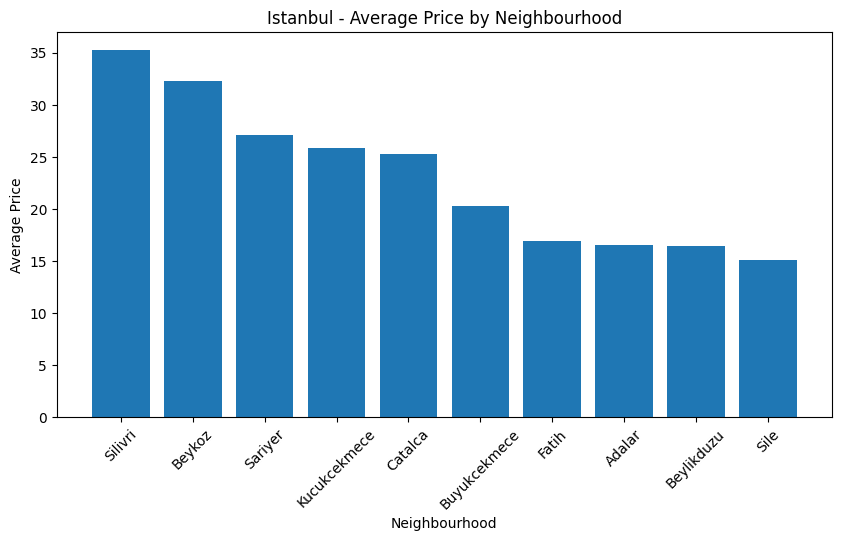

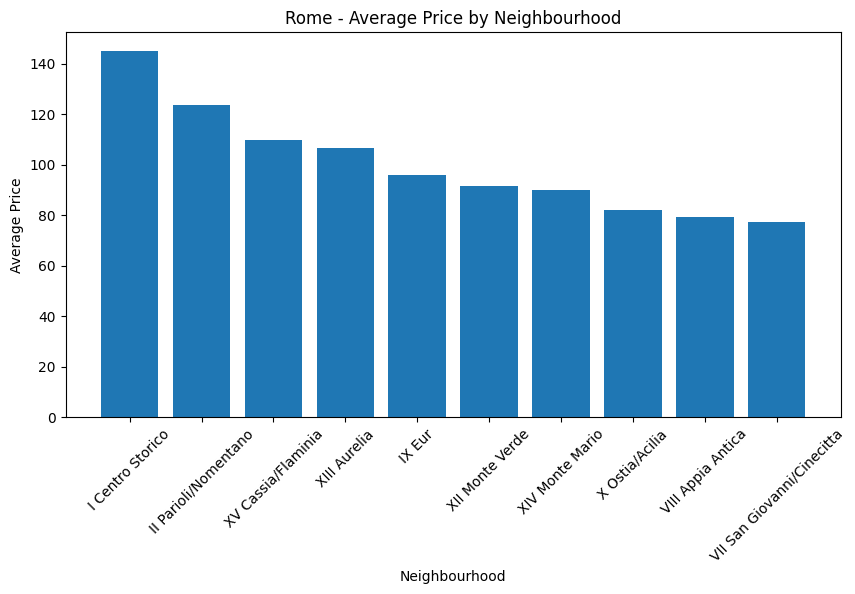

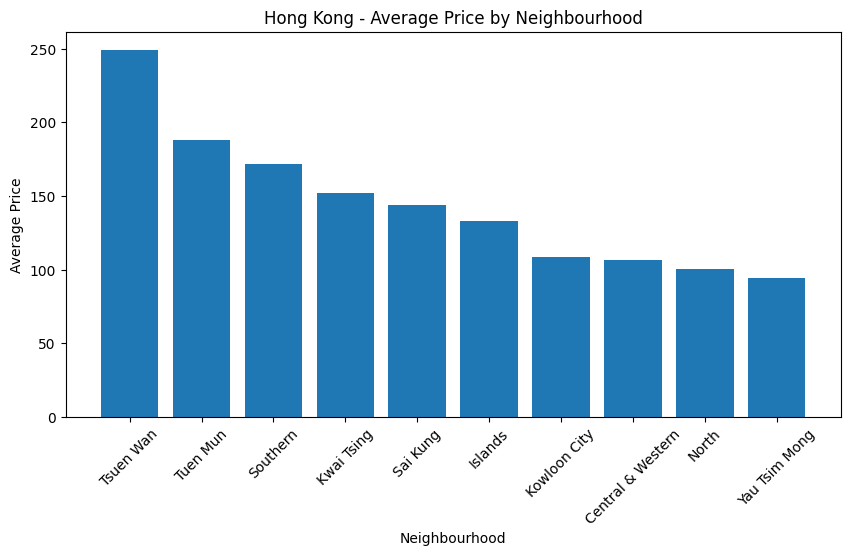

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129 (\x81) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


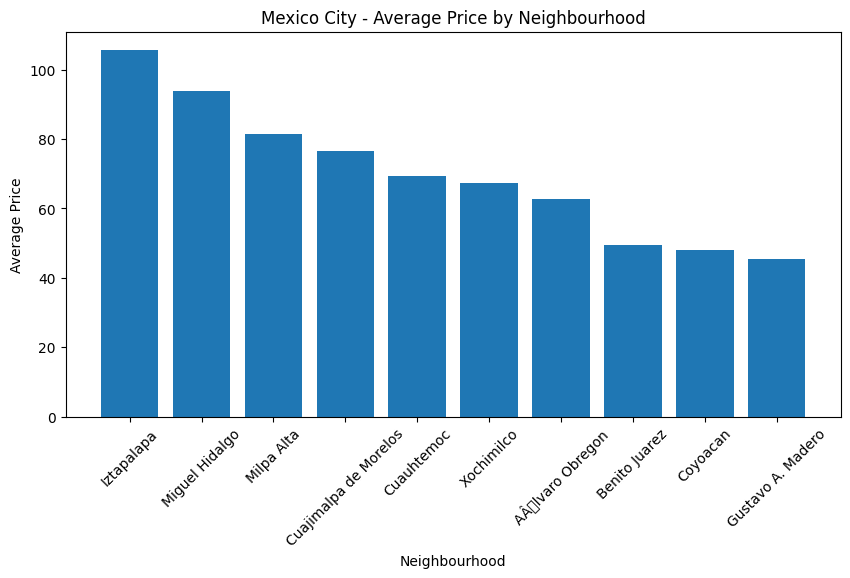

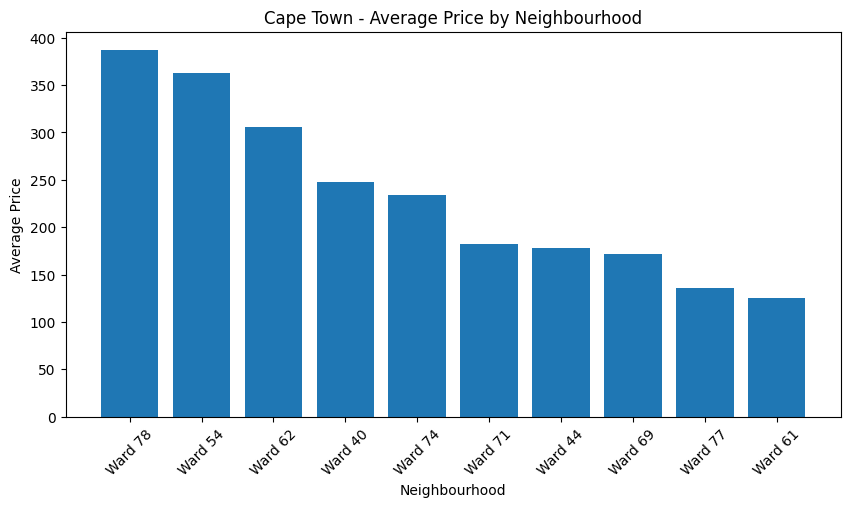

In [9]:
cities = airbnb_proj_cleaned['city'].dropna().unique()
cities
    
for city in cities:
    
    city_data = airbnb_proj_cleaned[airbnb_proj_cleaned['city'] == city]
    neighbourhood_price = (city_data
        .groupby('neighbourhood')['price_usd']
        .mean()
        .sort_values(ascending=False)
        .head(10)
        )
    
    plt.figure(figsize=(10,5))
    
    plt.bar(neighbourhood_price.index, neighbourhood_price.values)
    
    plt.title(f"{city} - Average Price by Neighbourhood")
    plt.xlabel("Neighbourhood")
    plt.ylabel("Average Price")
    
    plt.xticks(rotation=45)
    plt.show()

## 3. Geospatial Analysis

tourist hotspots
luxury zones
underpriced areas

In [10]:
city_map = airbnb_proj_cleaned.groupby('city').agg({
    'latitude':'mean',
    'longitude':'mean',
    'price_usd':'mean'
}).reset_index()

fig = px.scatter_mapbox(
    city_map,
    lat="latitude",
    lon="longitude",
    size="price_usd",
    color="price_usd",
    hover_name="city",
    zoom=1,
    height=600
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

C:\Users\lacho\AppData\Local\Temp\ipykernel_25532\3853307748.py:7: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


## 4. Demand Analysis

### 4.1 Global Airbnb Demand Over Time

In [11]:
# Convert date and create year/month

reviews['date'] = pd.to_datetime(reviews['date'])

reviews['year'] = reviews['date'].dt.year
reviews['month'] = reviews['date'].dt.month

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


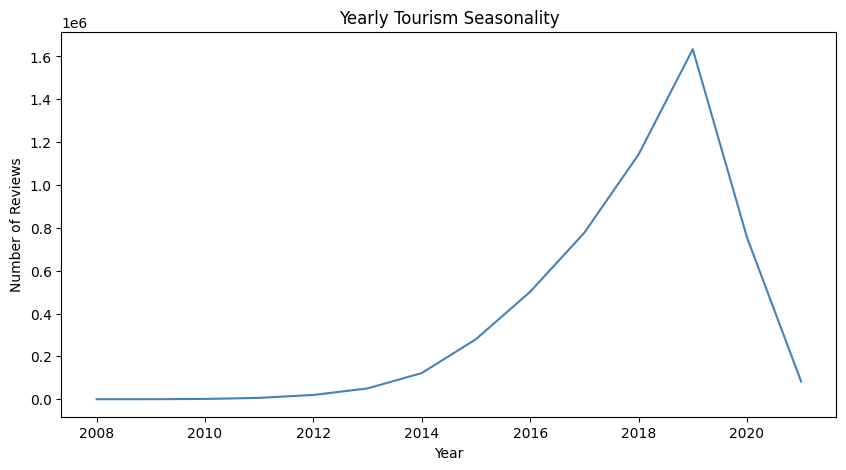

In [12]:
yearly_reviews = (
    reviews.groupby('year')
    .size()
    .reset_index(name='review_count')
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=yearly_reviews,
    x='year',
    y='review_count',
    color='steelblue'
)

plt.title("Yearly Tourism Seasonality")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()

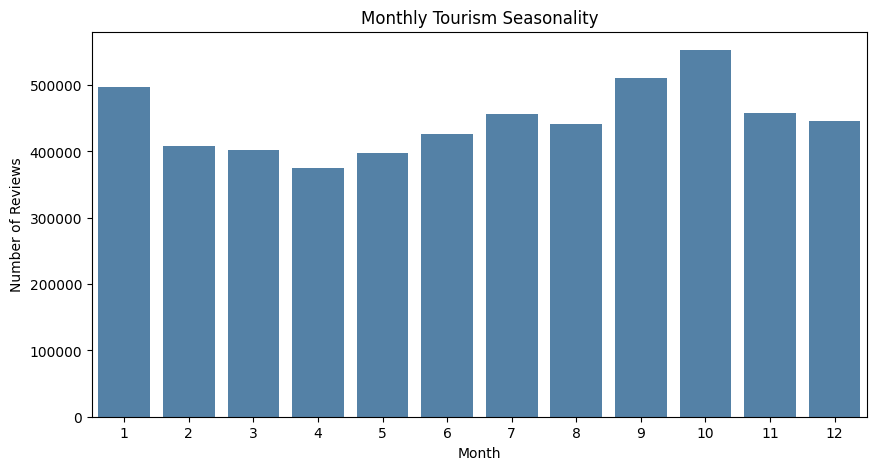

In [13]:
monthly_reviews = (
    reviews.groupby('month')
    .size()
    .reset_index(name='review_count')
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly_reviews,
    x='month',
    y='review_count',
    color='steelblue'
)

plt.title("Monthly Tourism Seasonality")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")
plt.show()

### 4.2 Yearly Review Trend for Each City

In [14]:
yearly_city = (
    reviews_cleaned
    .groupby(['city', 'year'])['review_count_city']
    .sum()
    .reset_index()
)

yearly_city.head()

,city,year,review_count_city
0,Bangkok,2010,2
1,Bangkok,2011,44
2,Bangkok,2012,3665
3,Bangkok,2013,17900
4,Bangkok,2014,72731


In [15]:
yearly_city['review_million'] = (
    yearly_city['review_count_city'] / 1_000_000
)

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

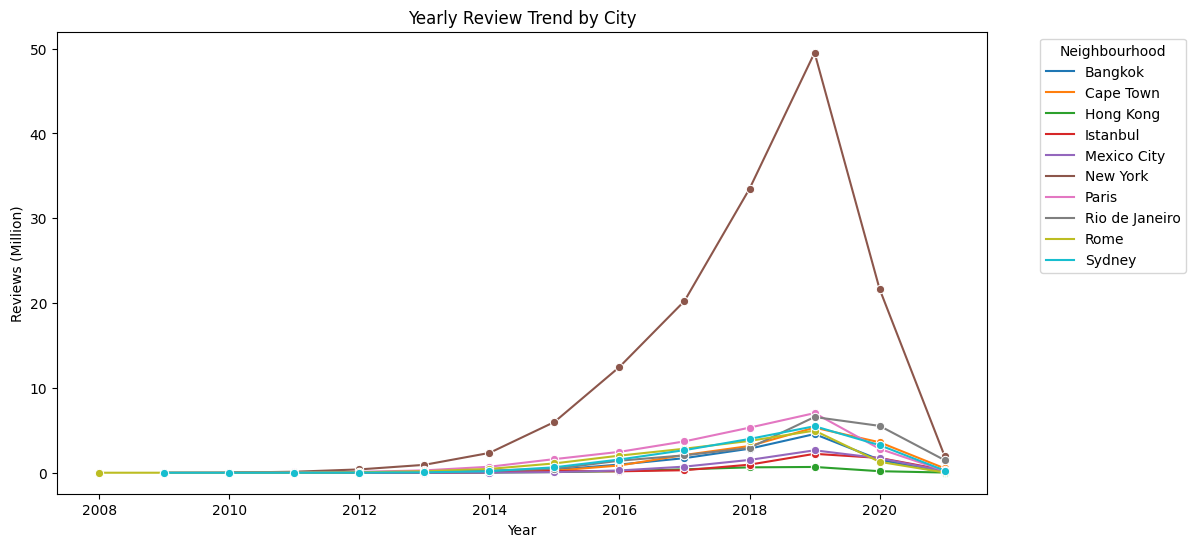

In [16]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=yearly_city,
    x='year',
    y='review_million',
    hue='city',
    marker='o'
)
plt.legend(
        title="Neighbourhood",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )
plt.title("Yearly Review Trend by City")
plt.xlabel("Year")
plt.ylabel("Reviews (Million)")

plt.show()

### 4.3 Monthly Review Trend for Each City

In [17]:
monthly_city = (
    reviews_cleaned
    .groupby(['city', 'month'])['review_count_city']
    .sum()
    .reset_index()
)

monthly_city.head()

,city,month,review_count_city
0,Bangkok,1,1529693
1,Bangkok,2,1253607
2,Bangkok,3,1011730
3,Bangkok,4,792468
4,Bangkok,5,728561


In [18]:
monthly_city['review_million'] = (
    monthly_city['review_count_city'] / 1000000
)

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

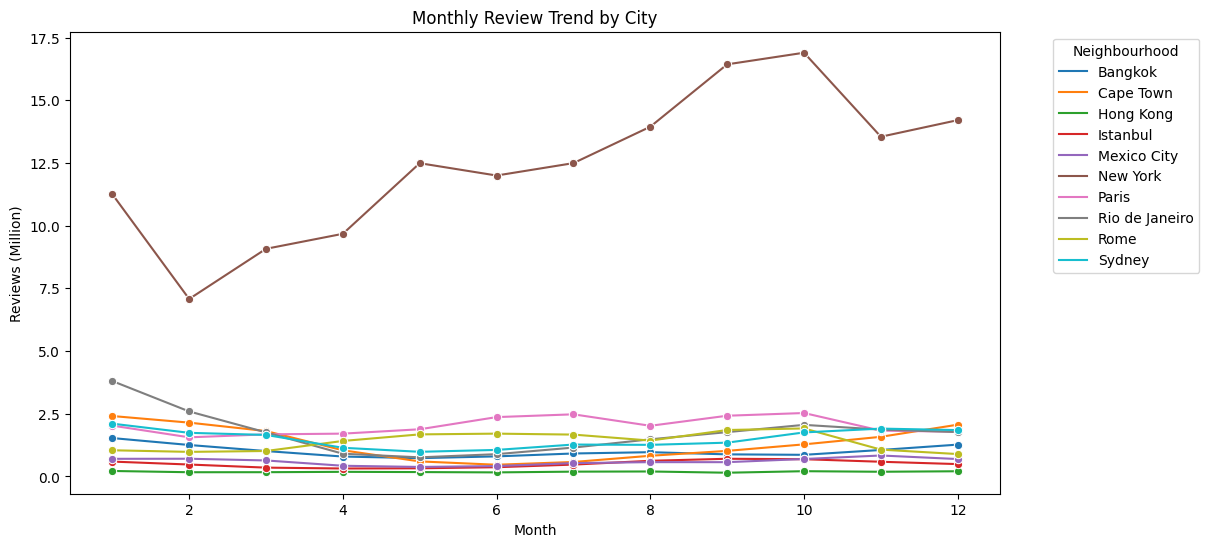

In [19]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_city,
    x='month',
    y='review_million',
    hue='city',
    marker='o'
)
plt.legend(
        title="Neighbourhood",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

plt.title("Monthly Review Trend by City")
plt.xlabel("Month")
plt.ylabel("Reviews (Million)")

plt.show()

### 4.4 Yearly Review Trend for top 10 Neighborhood in Each City

In [20]:
# Find top 10 neighbourhoods for each city

top_n = 10

top_neighbourhoods = (
    reviews_cleaned
    [['city', 'neighbourhood', 'total_reviews_neighbourhood']]
    .drop_duplicates()
    .sort_values(
        ['city', 'total_reviews_neighbourhood'],
        ascending=[True, False]
    )
    .groupby('city')
    .head(top_n)
)

top_neighbourhoods.head()

,city,neighbourhood,total_reviews_neighbourhood
1558,Bangkok,Khlong Toei,38994
3218,Bangkok,Vadhana,35890
1283,Bangkok,Huai Khwang,22909
2614,Bangkok,Ratchathewi,22201
2874,Bangkok,Sathon,20723


In [21]:
# Merge with monthly demand data

neighbourhood_trend = reviews_cleaned.merge(
    top_neighbourhoods[
        ['city','neighbourhood']
    ],
    on=['city','neighbourhood'],
    how='inner'
)

neighbourhood_trend.head()

,city,neighbourhood,year,month,date,review_count_neighbourhood,review_count_city,total_reviews_neighbourhood
0,Bangkok,Bang Rak,2011,2,2011-02-01,1,2,18285
1,Bangkok,Bang Rak,2011,3,2011-03-01,1,1,18285
2,Bangkok,Bang Rak,2011,6,2011-06-01,2,2,18285
3,Bangkok,Bang Rak,2011,8,2011-08-01,2,3,18285
4,Bangkok,Bang Rak,2011,10,2011-10-01,1,3,18285


C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

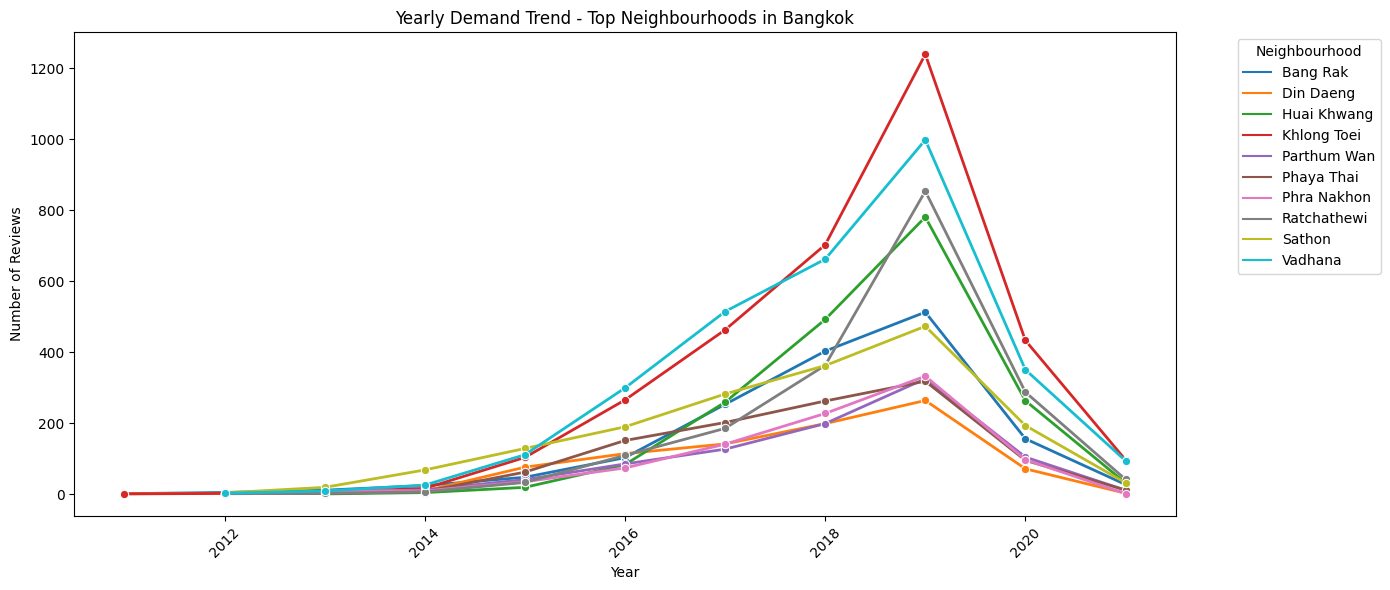

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

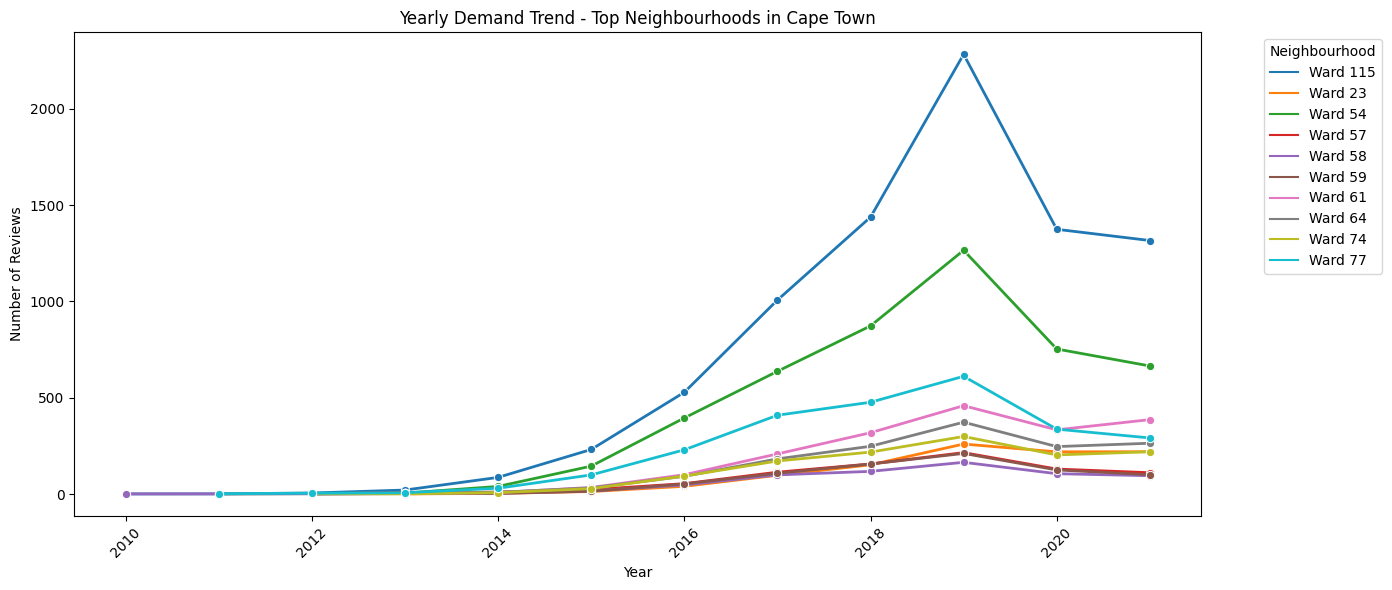

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

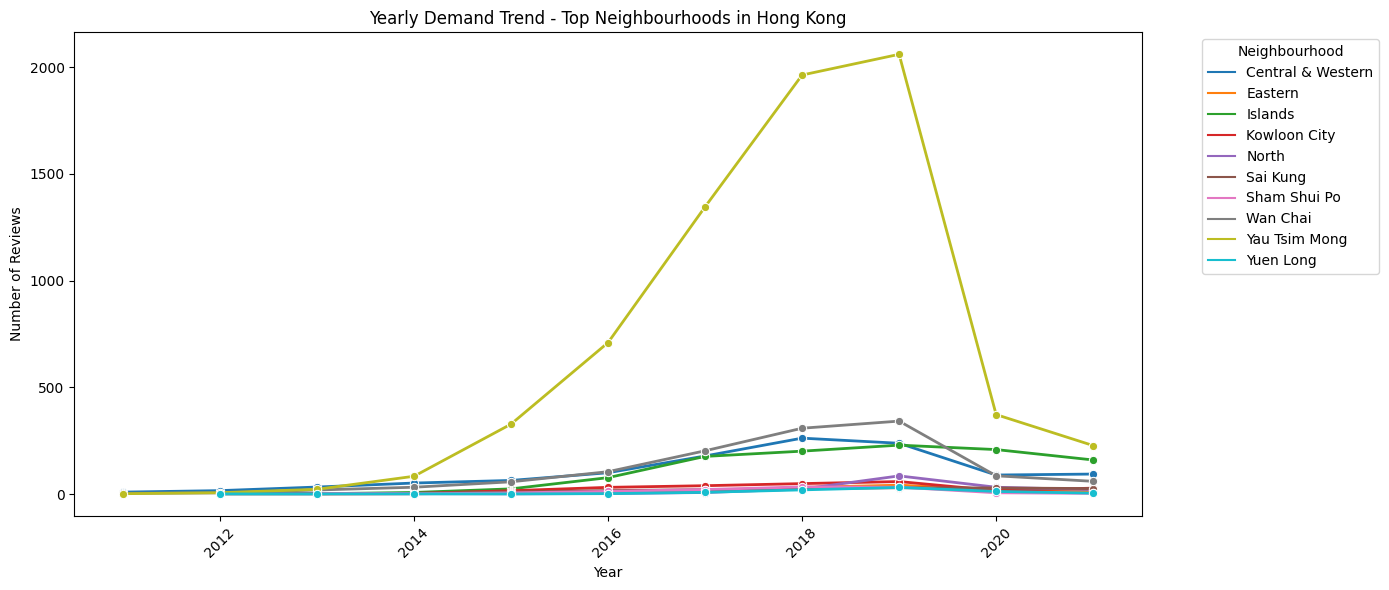

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

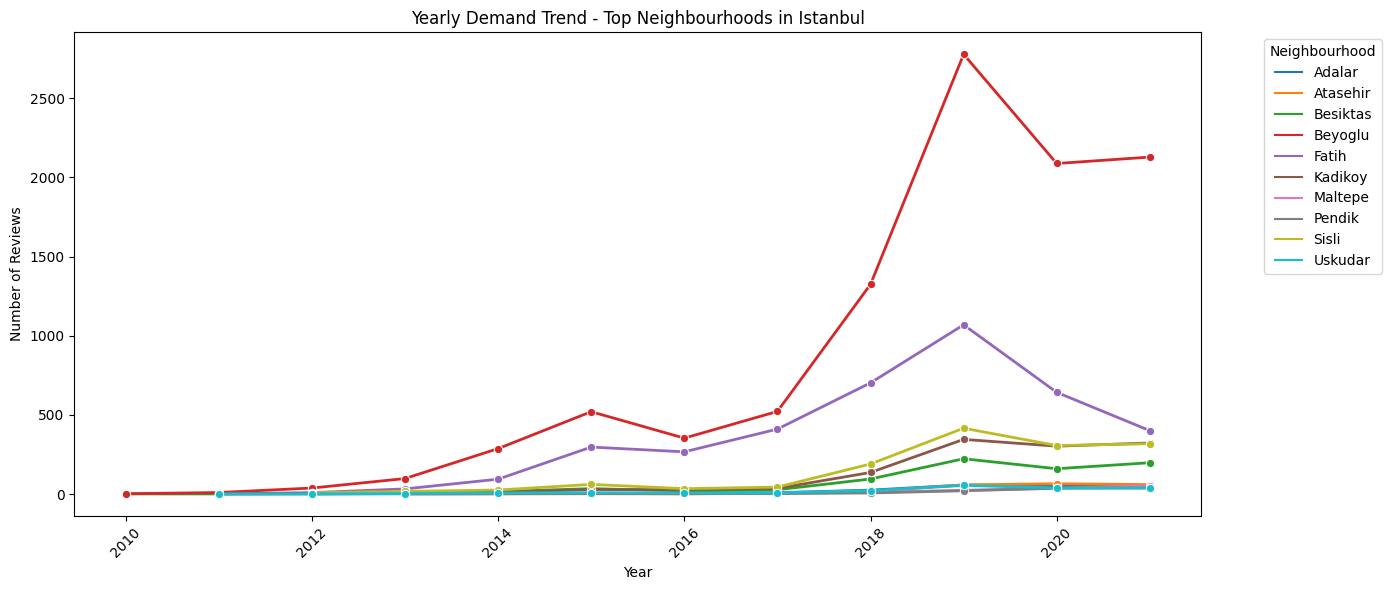

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

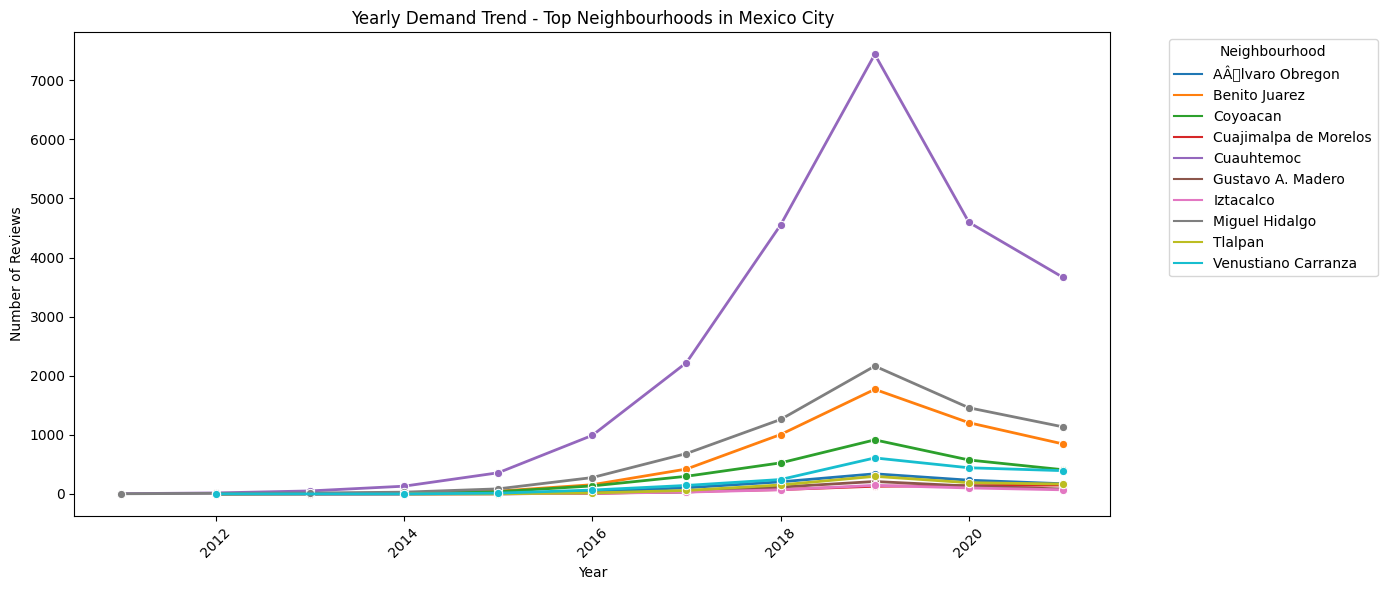

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

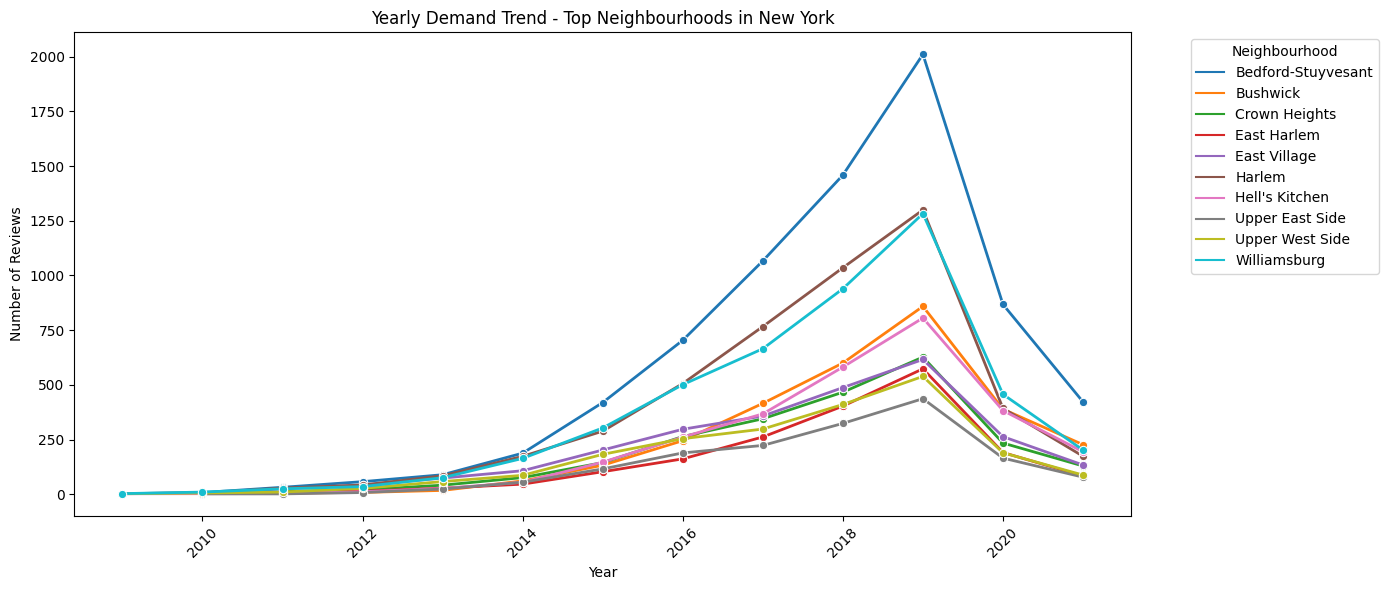

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

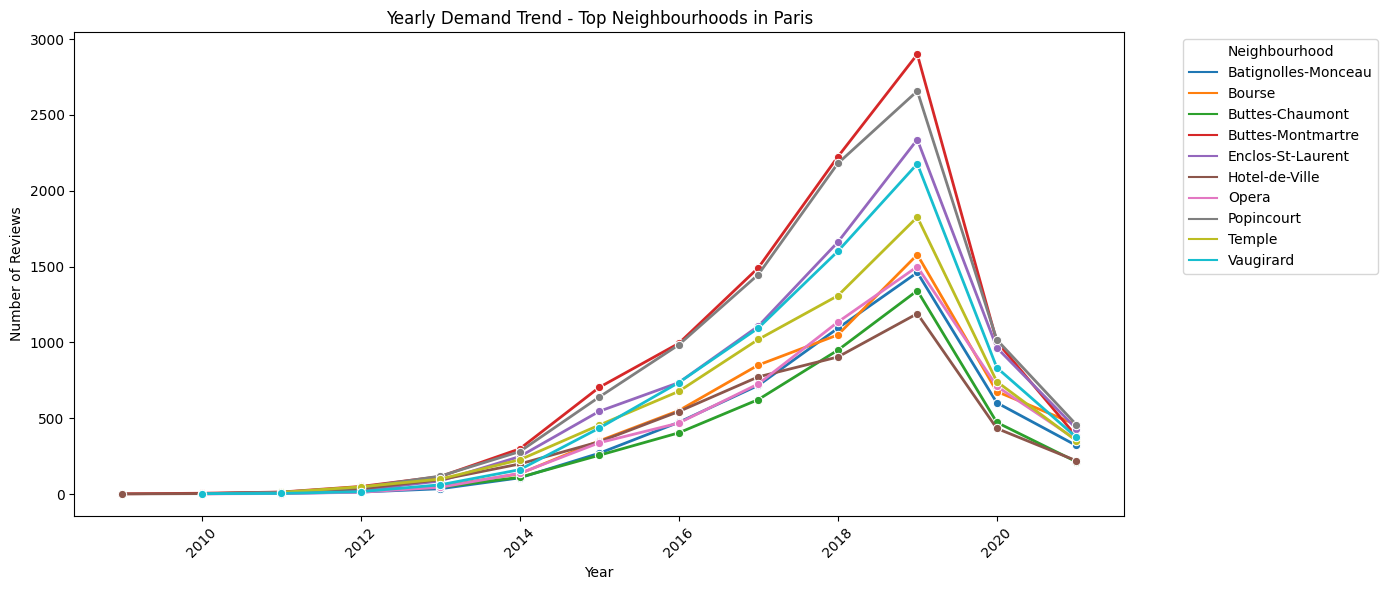

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

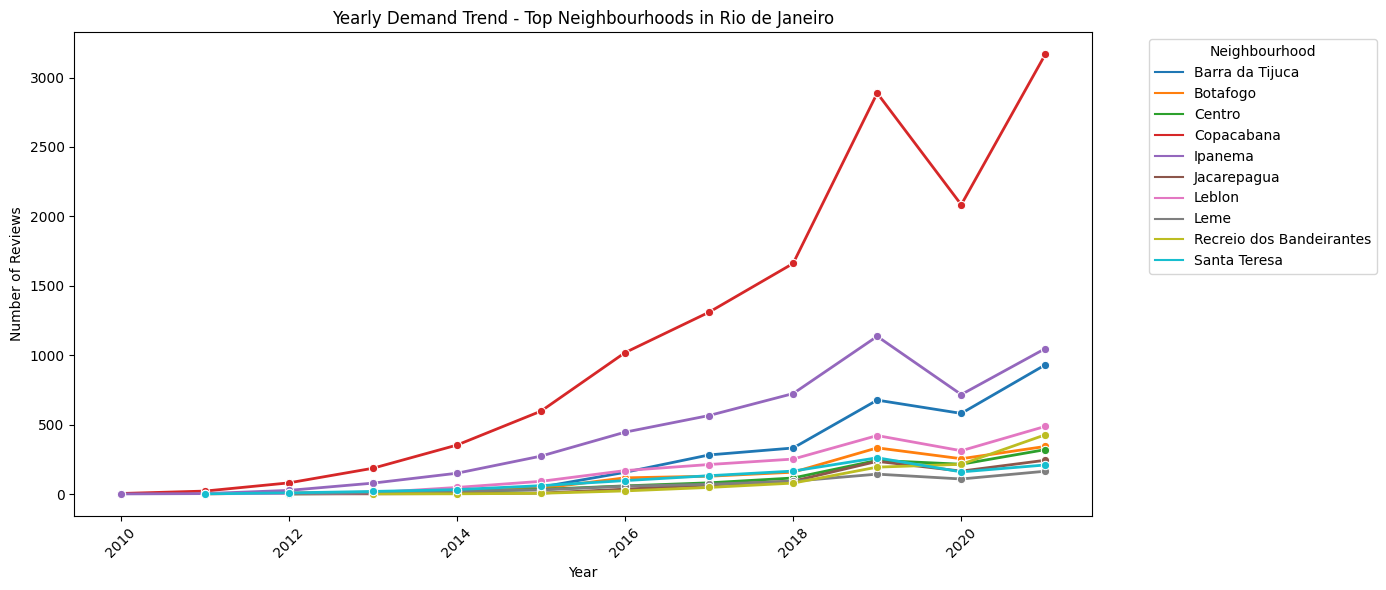

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

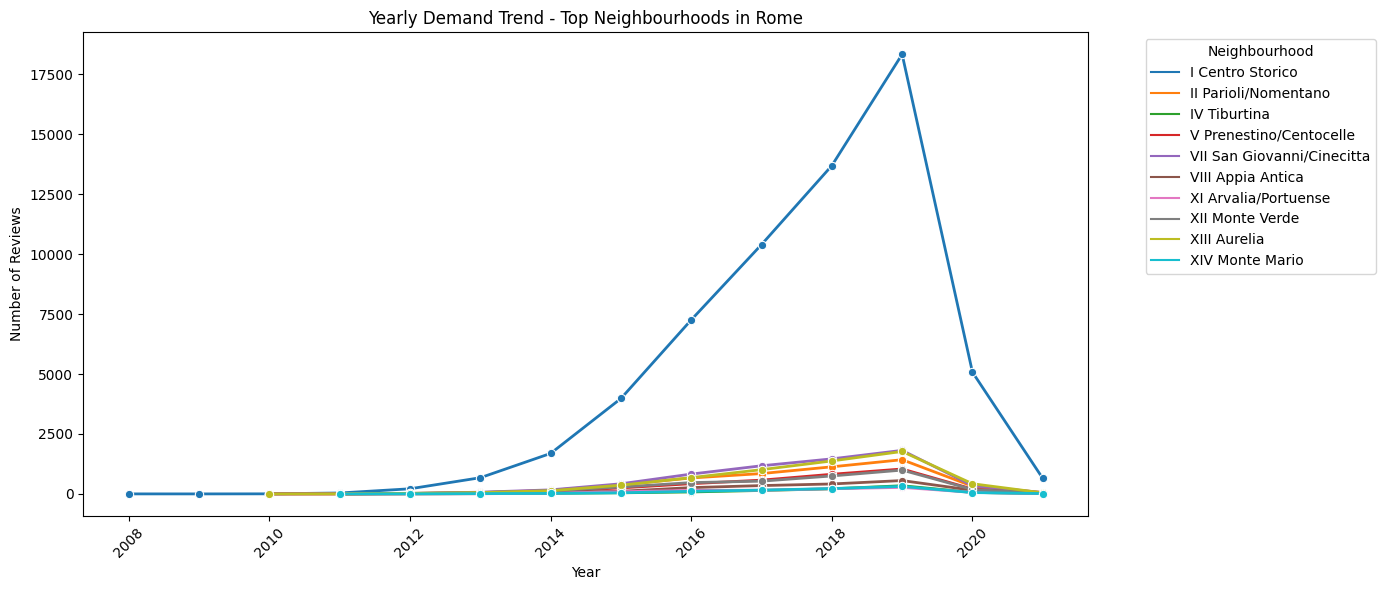

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

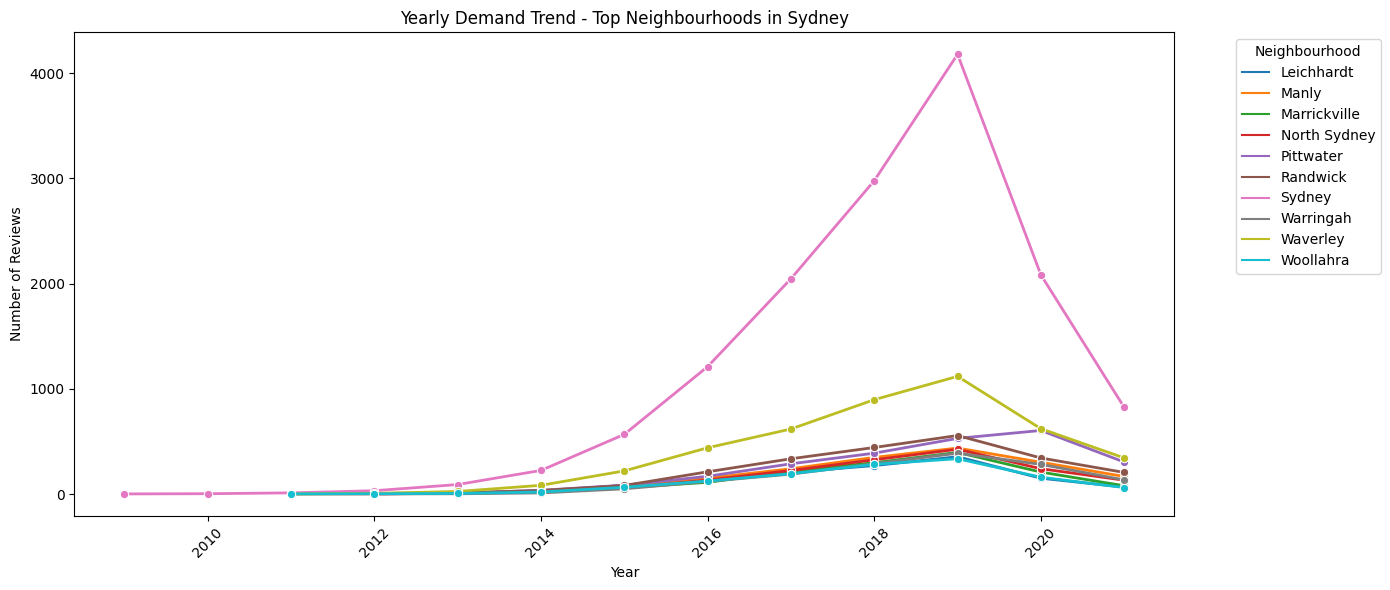

In [22]:
cities = reviews_cleaned['city'].unique()

for city in cities:

    city_data = neighbourhood_trend[
        neighbourhood_trend['city'] == city
    ]

    plt.figure(figsize=(14,6))

    sns.lineplot(
        data=city_data,
        x='year',
        y='review_count_neighbourhood',
        hue='neighbourhood',
        errorbar=None,       # remove shaded area
        linewidth=2,
        marker='o'
    )

    plt.title(
        f"Yearly Demand Trend - Top Neighbourhoods in {city}"
    )

    plt.xlabel("Year")
    plt.ylabel("Number of Reviews")

    plt.xticks(rotation=45)

    plt.legend(
        title="Neighbourhood",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()

### 4.5 Monthly Review Trend for top 10 Neighborhood in Each City

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

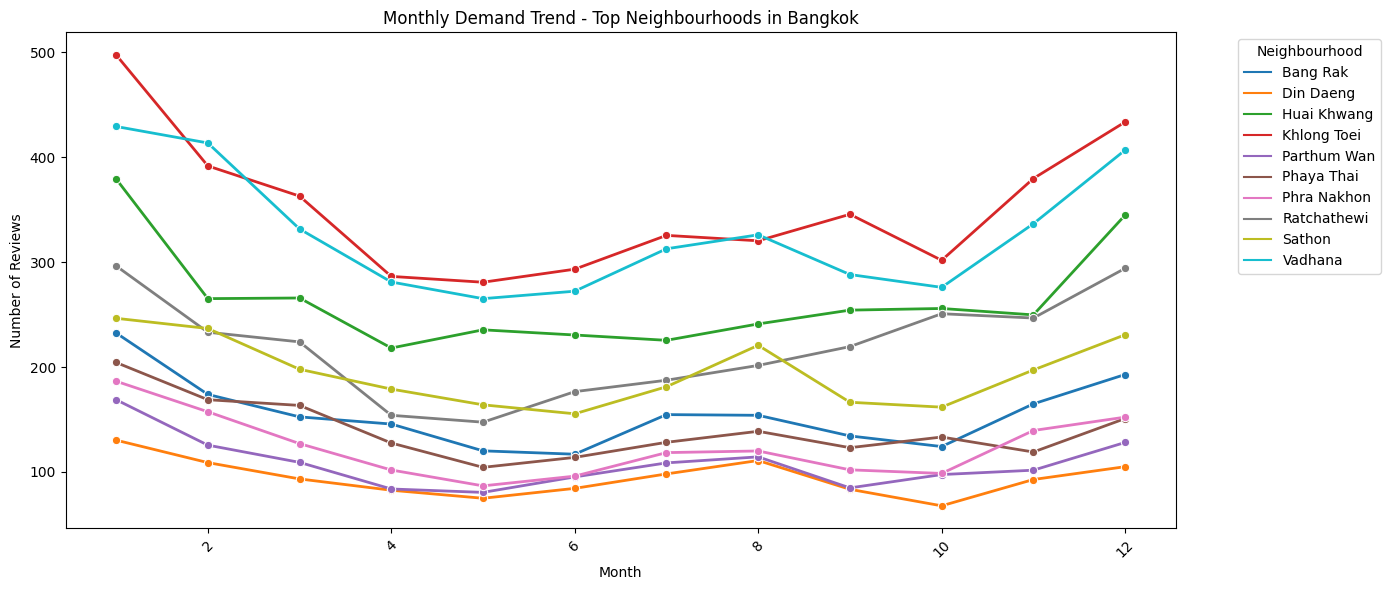

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

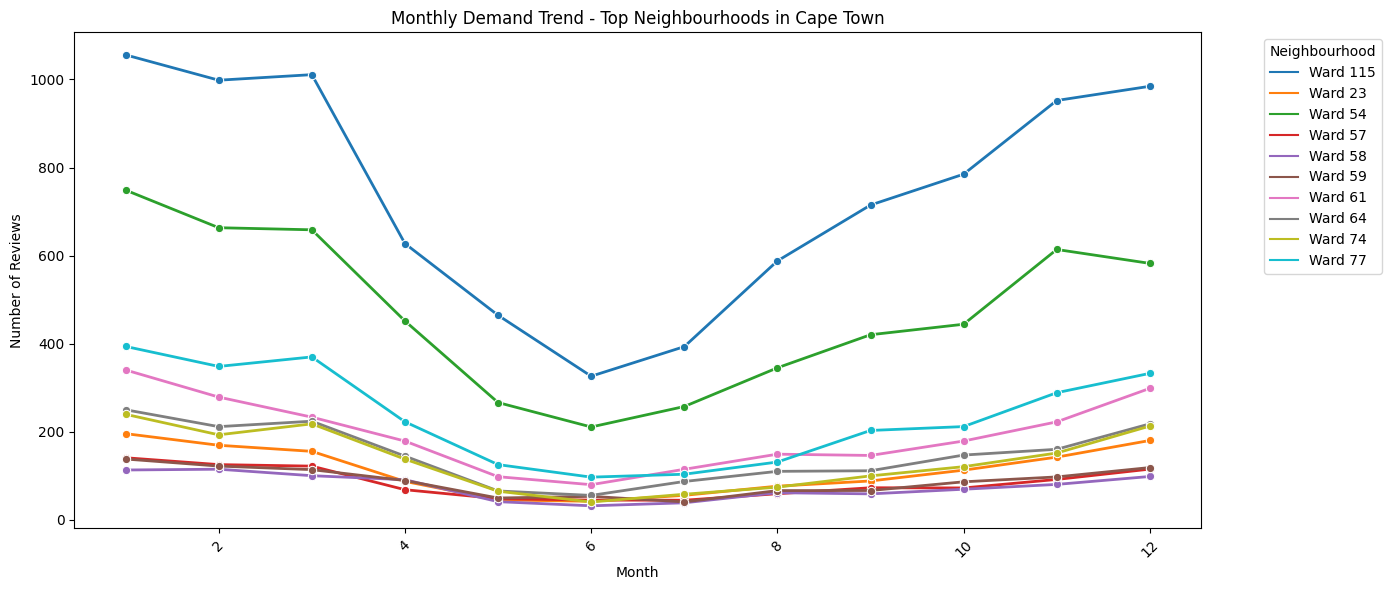

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

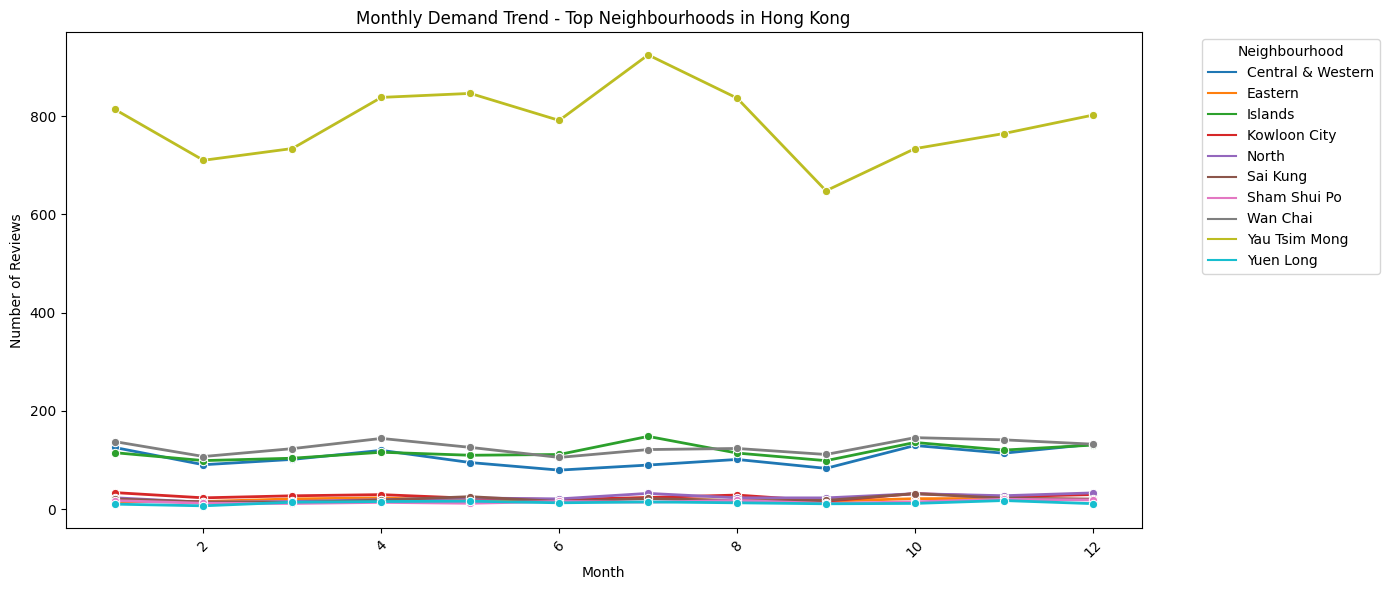

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

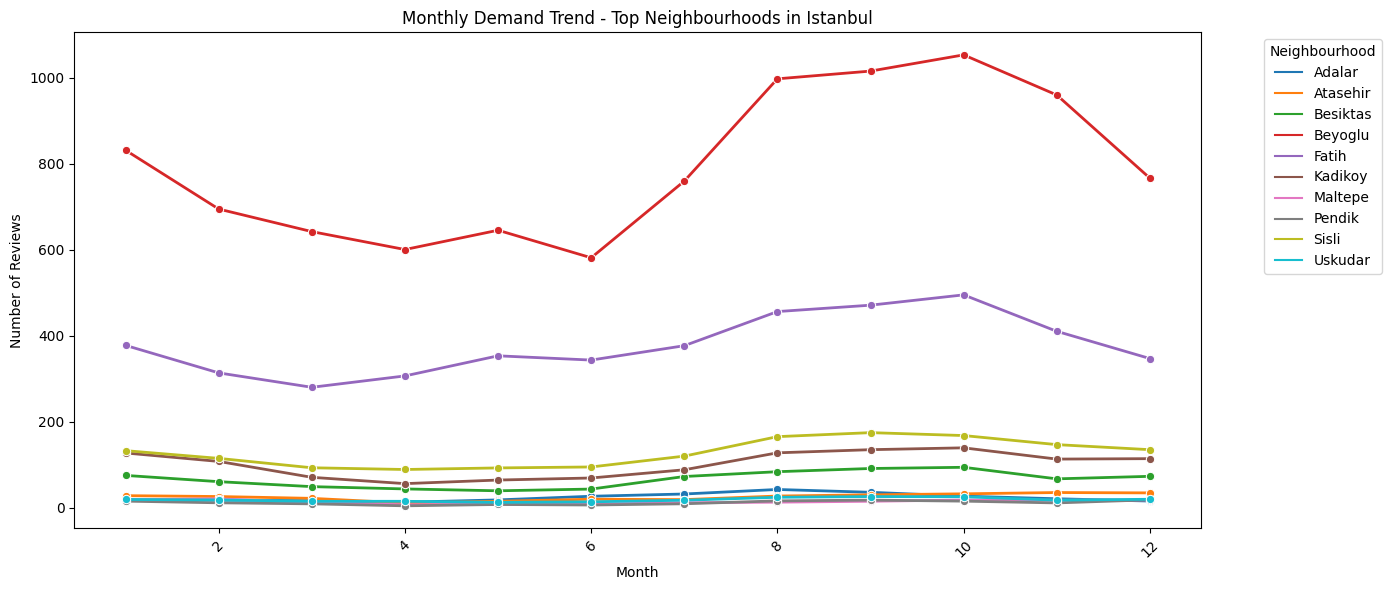

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

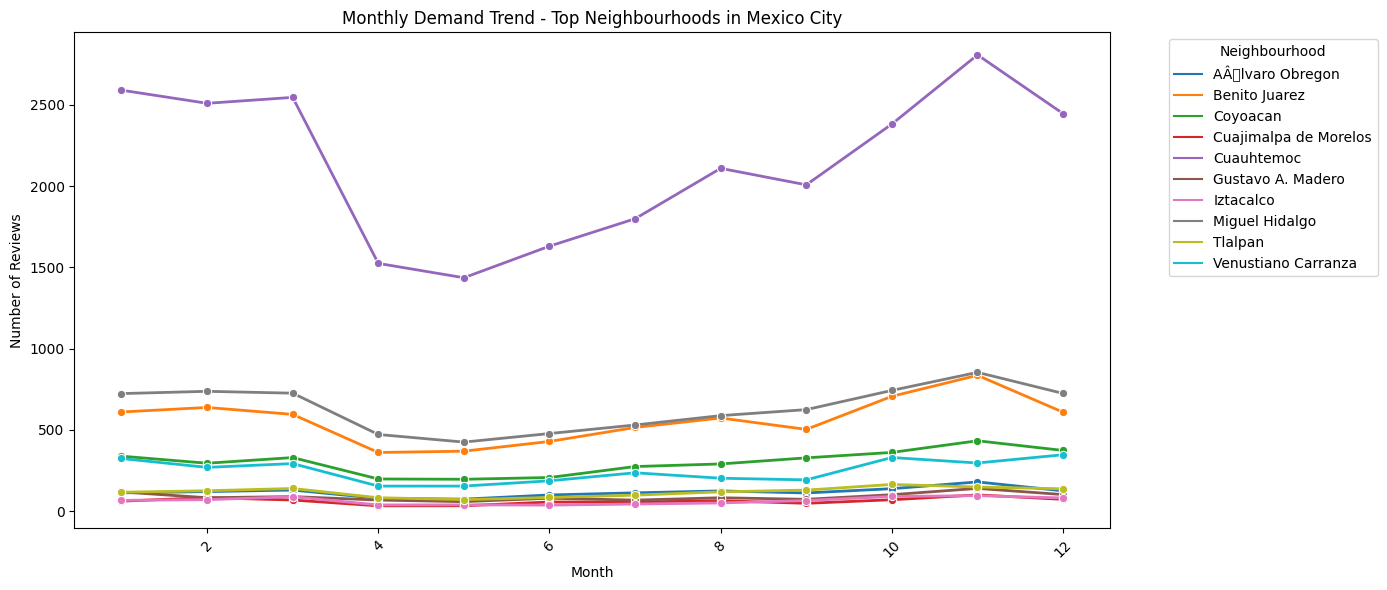

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

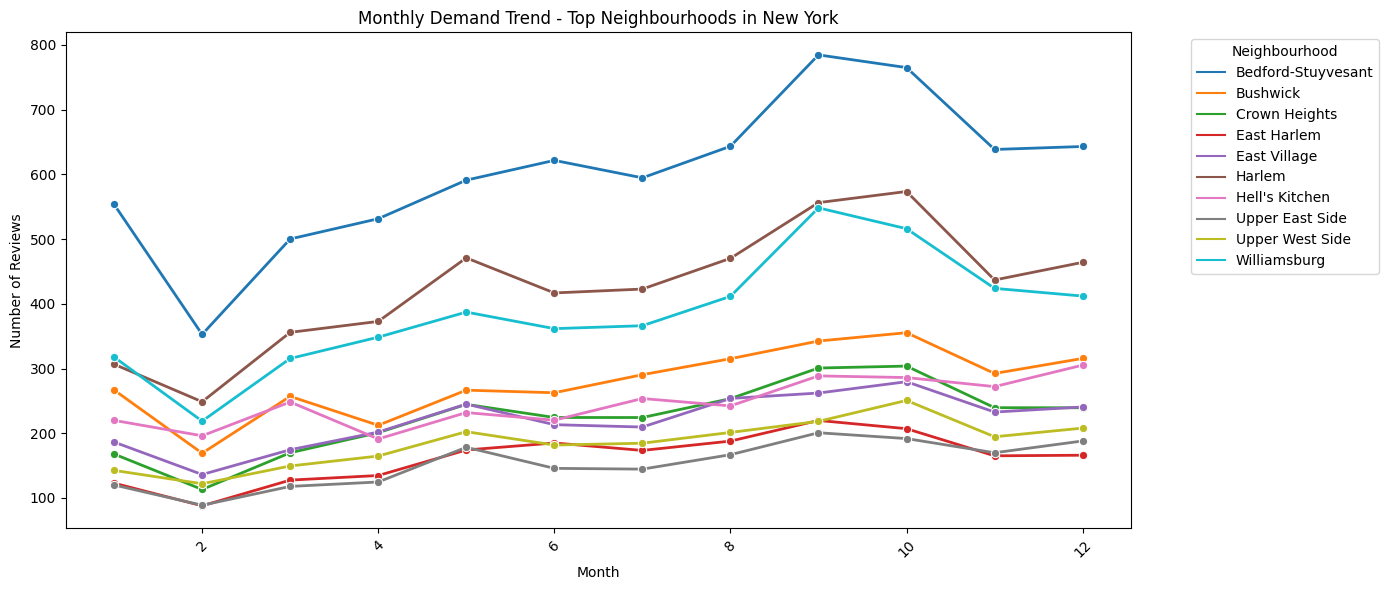

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

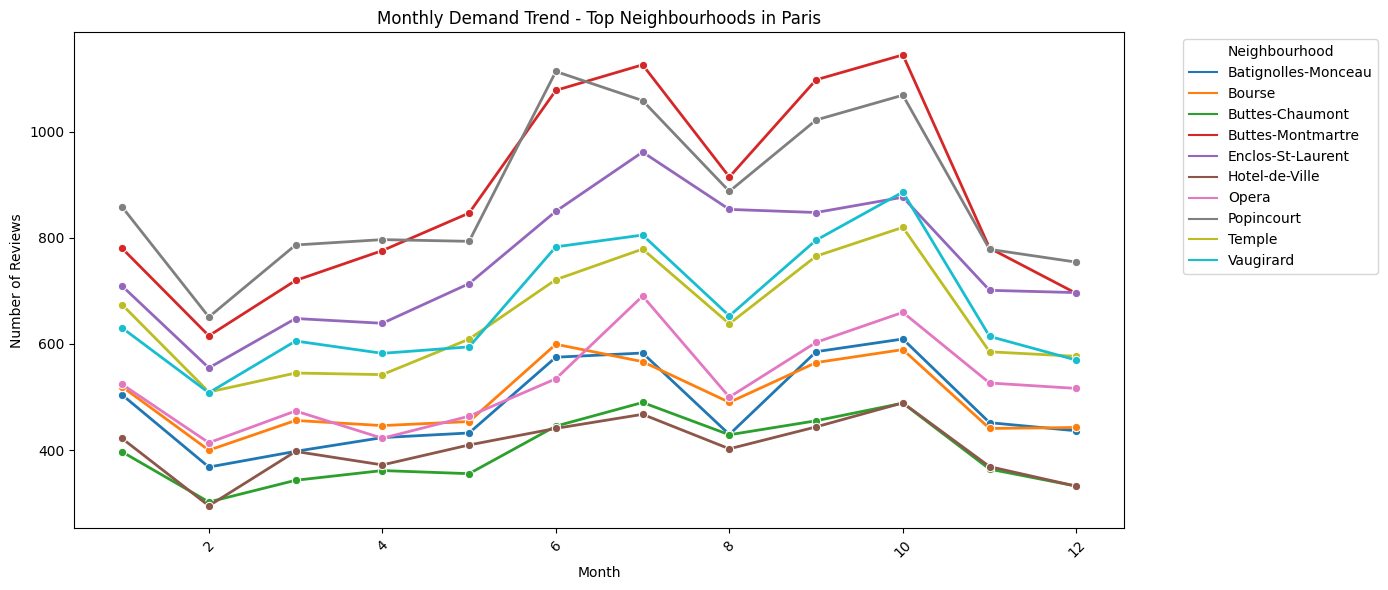

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

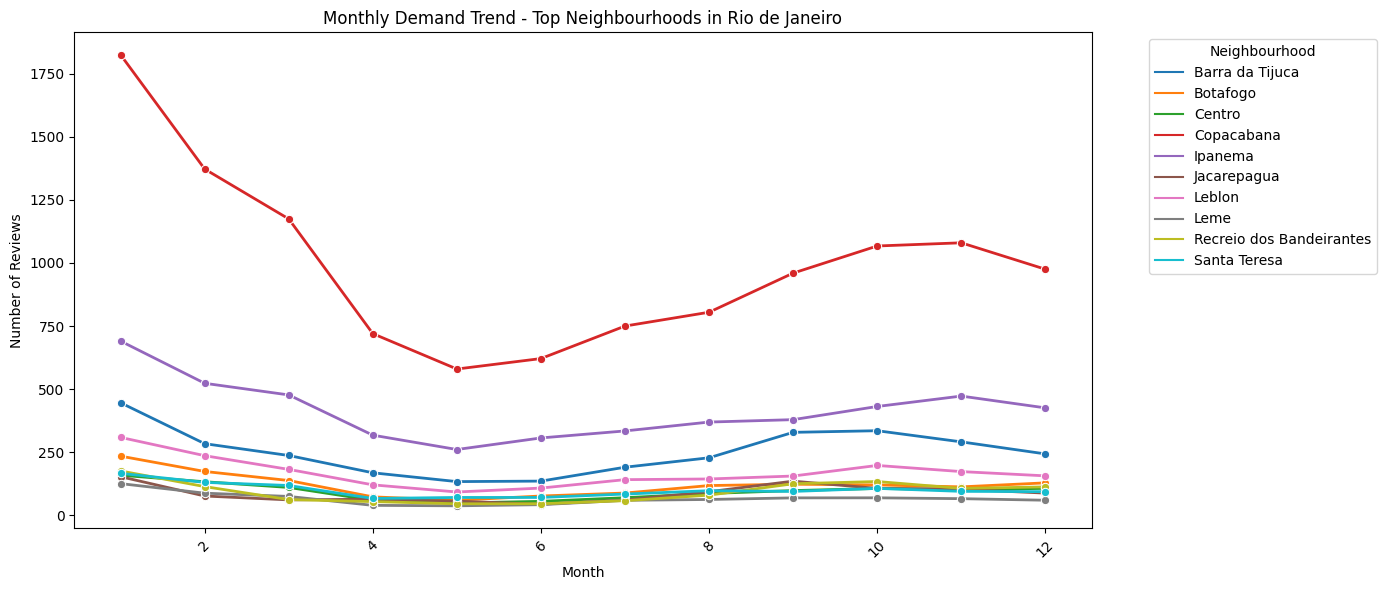

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

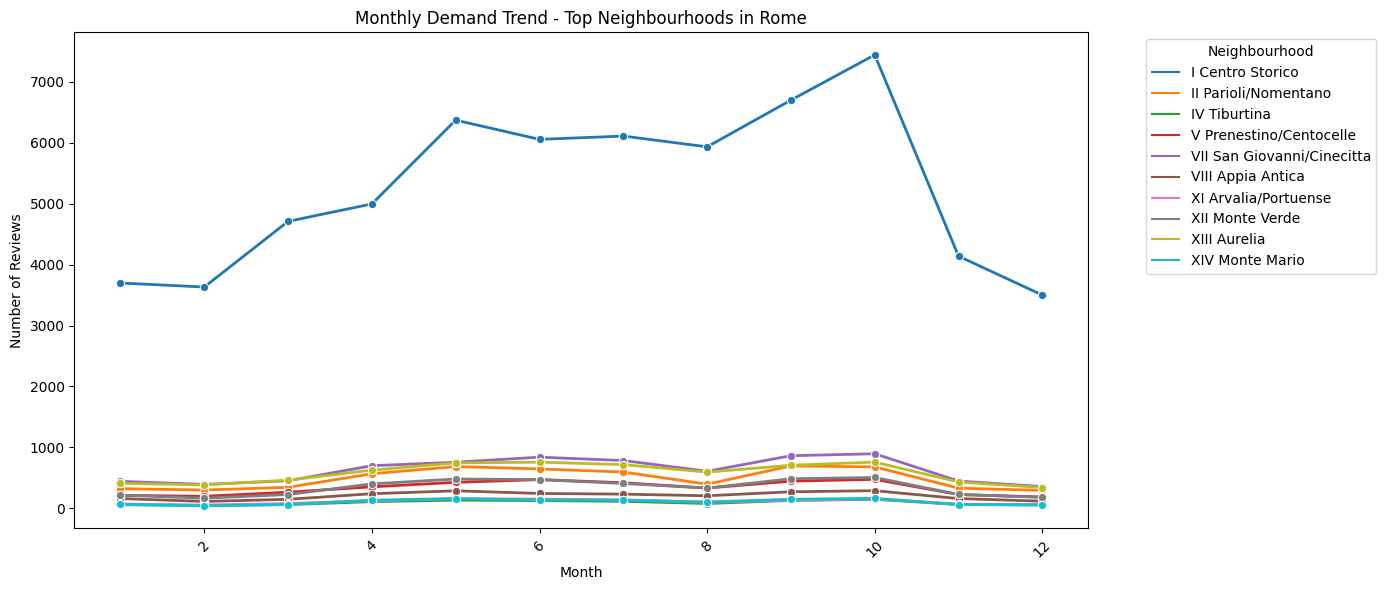

C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\lacho\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in 

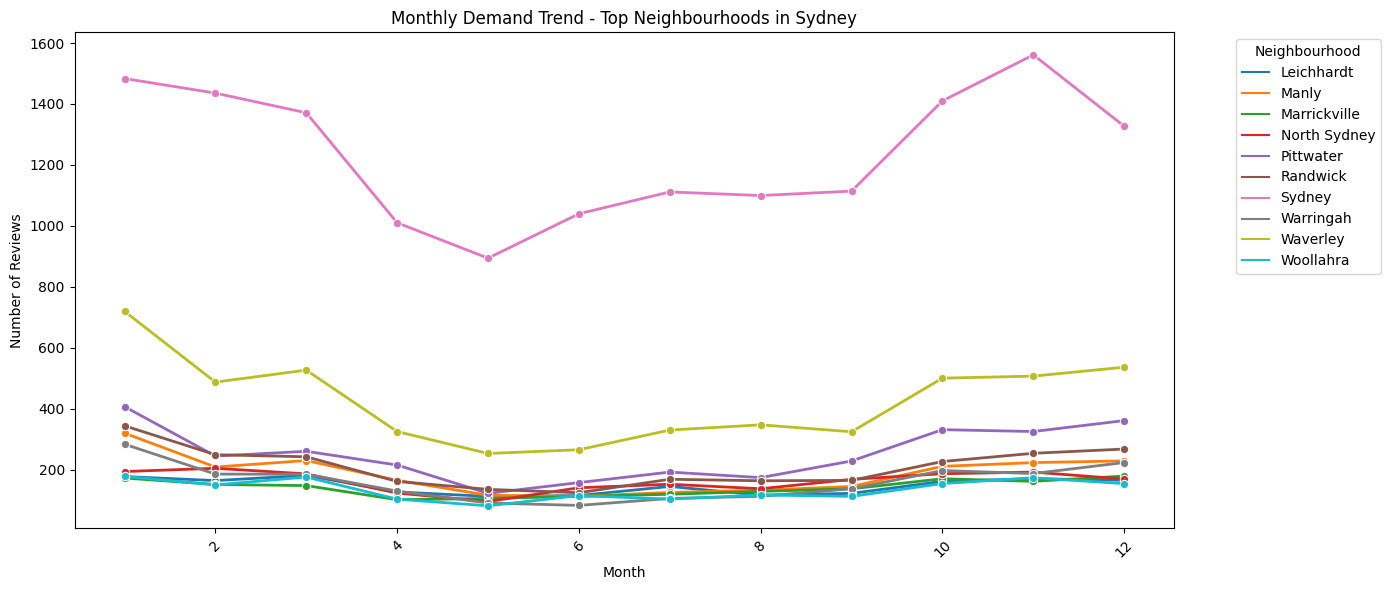

In [23]:
cities = reviews_cleaned['city'].unique()

for city in cities:

    city_data = neighbourhood_trend[
        neighbourhood_trend['city'] == city
    ]

    plt.figure(figsize=(14,6))

    sns.lineplot(
        data=city_data,
        x='month',
        y='review_count_neighbourhood',
        hue='neighbourhood',
        errorbar=None,       # remove shaded area
        linewidth=2,
        marker='o'
    )

    plt.title(
        f"Monthly Demand Trend - Top Neighbourhoods in {city}"
    )

    plt.xlabel("Month")
    plt.ylabel("Number of Reviews")

    plt.xticks(rotation=45)

    plt.legend(
        title="Neighbourhood",
        bbox_to_anchor=(1.05, 1),
        loc='upper left'
    )

    plt.tight_layout()
    plt.show()

### 4.6 Average Airbnb Rating by City

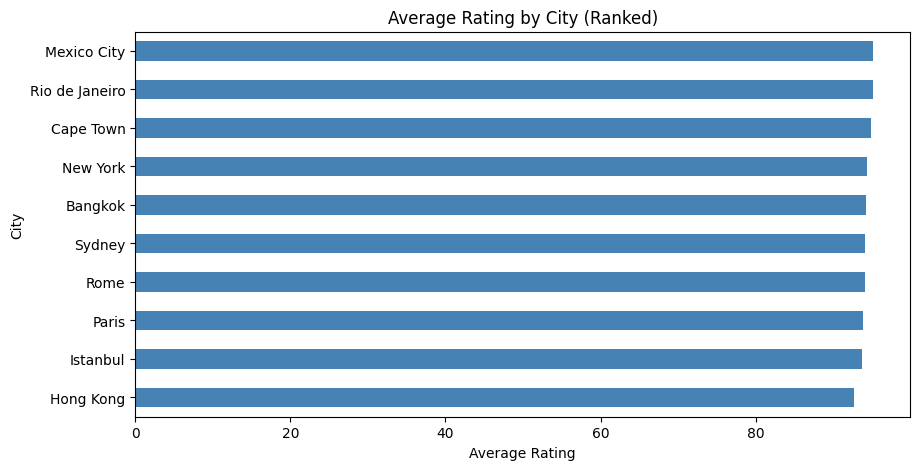

In [24]:
city_rating = (
    airbnb_proj_cleaned
    .groupby('city')['review_scores_rating']
    .mean()
    .sort_values(ascending=False)
)

city_rating

plt.figure(figsize=(10,5))

city_rating.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title("Average Rating by City (Ranked)")
plt.xlabel("Average Rating")
plt.ylabel("City")

plt.show()

### 4.7 City Rating vs Market Size

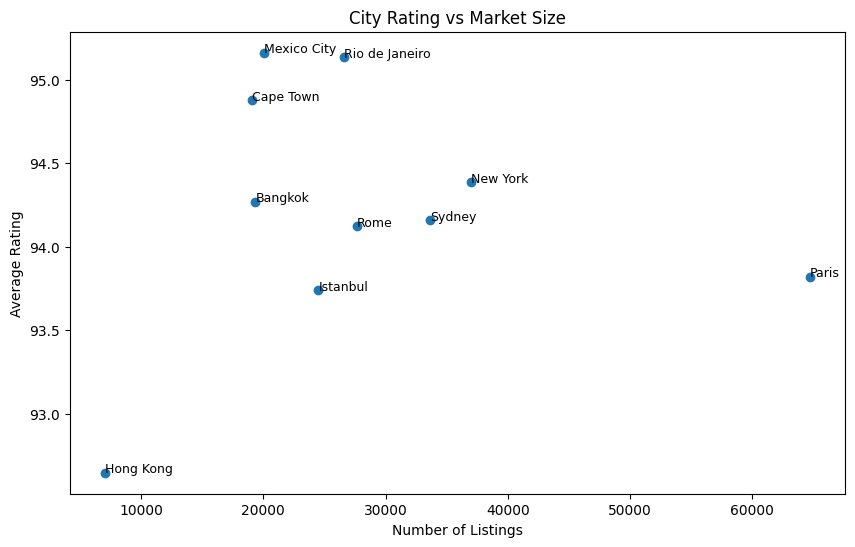

In [25]:
city_summary = (
    airbnb_proj_cleaned
    .groupby('city')
    .agg(
        avg_rating=('review_scores_rating', 'mean'),
        listings=('listing_id', 'count')
    )
    .reset_index()
    .sort_values('avg_rating', ascending=False)
)

plt.figure(figsize=(10,6))

plt.scatter(
    city_summary['listings'],
    city_summary['avg_rating']
)

for i in range(len(city_summary)):
    plt.text(
        city_summary['listings'].iloc[i],
        city_summary['avg_rating'].iloc[i],
        city_summary['city'].iloc[i],
        fontsize=9
    )

plt.title("City Rating vs Market Size")
plt.xlabel("Number of Listings")
plt.ylabel("Average Rating")

plt.show()